In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.metrics import ConfusionMatrixDisplay
from lazypredict.Supervised import LazyClassifier
import pickle



NaN counts in each column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


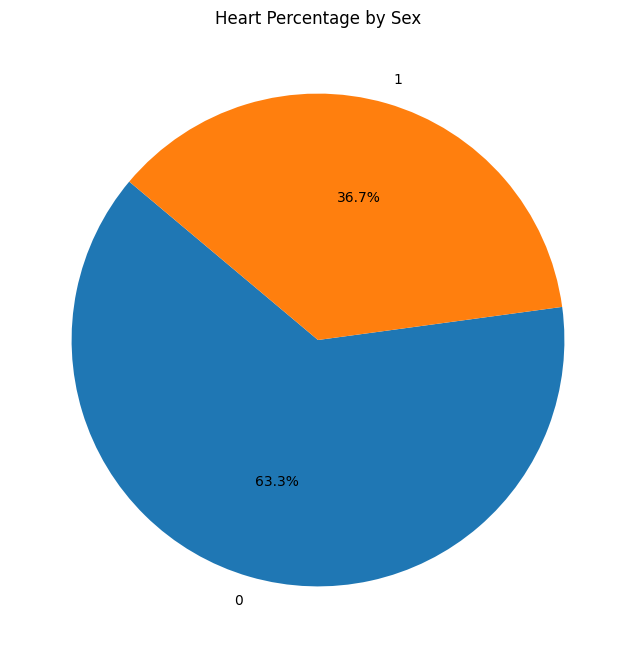

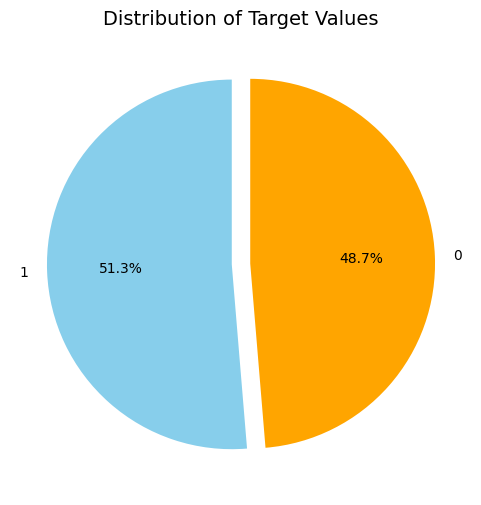

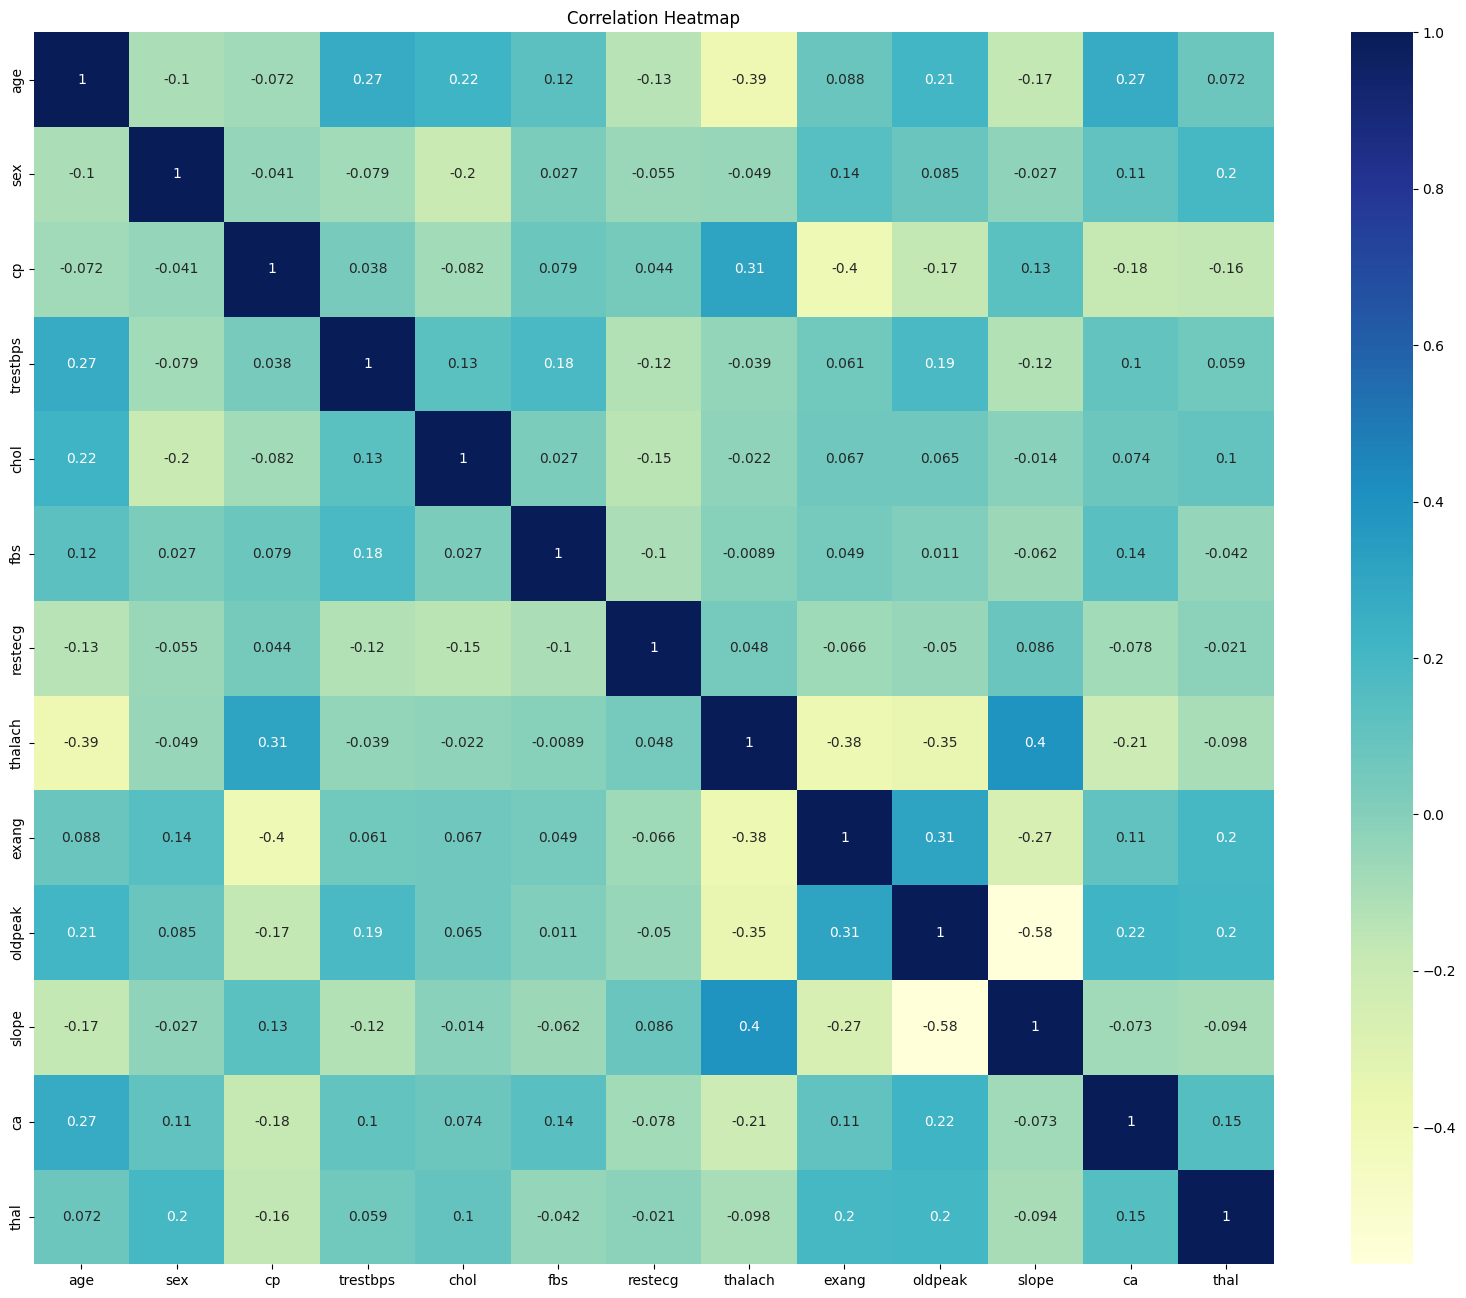

100%|██████████| 31/31 [00:00<00:00, 34.23it/s]


[LightGBM] [Info] Number of positive: 423, number of negative: 397
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000036 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 820, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515854 -> initscore=0.063436
[LightGBM] [Info] Start training from score 0.063436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
 

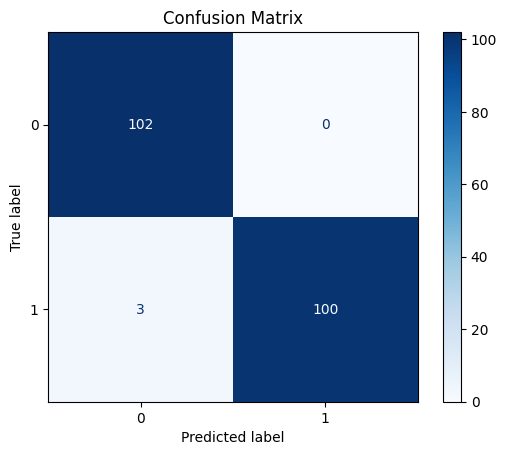

AUC = 1.00


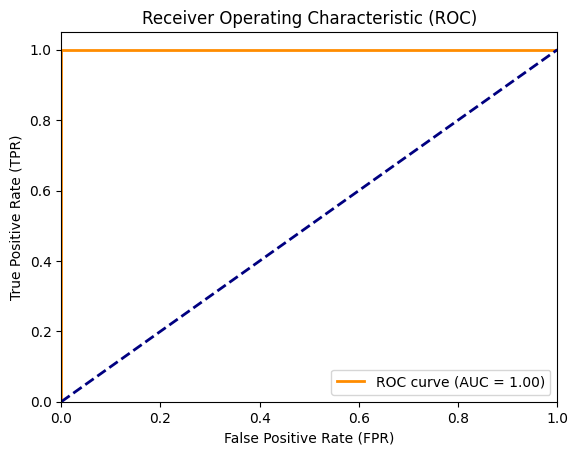

Best model has been saved to 'heartV1.pkl'.


In [2]:
class HeartDiseaseAnalysis:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def load_and_process_data(self):
        self.df = pd.read_csv(self.file_path)
        self.df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
                            'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
        self.df['target'] = self.df['target'].map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
        self.df = self.df.apply(pd.to_numeric, errors='coerce')

        nan_counts = self.df.isna().sum()
        print("NaN counts in each column:\n", nan_counts)
        self.df.dropna(inplace=True)

    def visualize_data(self):
        # Pie chart for 'target'
        target_counts = self.df['target'].value_counts()
        
        # Pie chart for 'sex'
        heart_percentages = self.df.groupby('sex')['target'].mean() * 100
        plt.figure(figsize=(8, 8))
        plt.pie(heart_percentages, labels=heart_percentages.index, autopct='%1.1f%%', startangle=140)
        plt.title('Heart Percentage by Sex')
        plt.show()
        
        plt.figure(figsize=(6, 6))
        plt.pie(
            target_counts,
            labels=target_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['skyblue', 'orange'],
            explode=[0.05] * len(target_counts)
        )
        plt.title('Distribution of Target Values', fontsize=14)
        plt.show()

        # Heatmap
        plt.figure(figsize=(20, 16))
        sns.heatmap(self.df.drop('target', axis=1).corr(), cmap="YlGnBu", annot=True)
        plt.title("Correlation Heatmap")
        plt.show()

    def preprocess_and_split(self):
        X = self.df.iloc[:, :-1].values
        y = self.df.iloc[:, -1].values
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    def lazy_classifier_analysis(self):
        clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
        models, predictions = clf.fit(self.X_train, self.X_test, self.y_train, self.y_test)
        print(models)

    def random_forest_grid_search(self):
        classifier = RandomForestClassifier(random_state=42)
        param_grid = {
            'max_depth': [None, 10, 20, 30],
            'max_features': ['sqrt', 'log2'],
            'min_samples_leaf': [1, 2, 4],
            'min_samples_split': [2, 5, 10],
            'n_estimators': [50, 100, 200]
        }

        grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, n_jobs=-1, error_score='raise')
        grid_search.fit(self.X_train, self.y_train)

        print("Best Parameters:", grid_search.best_params_)
        print("Best Cross-validation Accuracy:", grid_search.best_score_)

        return grid_search.best_estimator_

    def evaluate_model_and_plot_roc(self, model):
        y_pred = model.predict(self.X_test)

        accuracy_for_test = accuracy_score(self.y_test, y_pred)
        print('Accuracy for test set with best parameters = {:.2f}'.format(accuracy_for_test))
        print('\nClassification Report:\n', classification_report(self.y_test, y_pred))

        cm = confusion_matrix(self.y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Confusion Matrix")
        plt.show()

        # Plot ROC curve
        y_pred_prob = model.predict_proba(self.X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(self.y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)

        print('AUC = {:.2f}'.format(roc_auc))

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.title('Receiver Operating Characteristic (ROC)')
        plt.legend(loc="lower right")
        plt.show()

# Sử dụng lớp
if __name__ == "__main__":
    analysis = HeartDiseaseAnalysis('heart.csv')
    analysis.load_and_process_data()
    analysis.visualize_data()
    analysis.preprocess_and_split()
    analysis.lazy_classifier_analysis()
    best_model = analysis.random_forest_grid_search()
    analysis.evaluate_model_and_plot_roc(best_model)

    with open('heartV1.pkl', 'wb') as file:
        pickle.dump(best_model, file)
    print("Best model has been saved to 'heartV1.pkl'.")
